<a href="https://colab.research.google.com/github/AliAch04/TensorFlow-projs/blob/main/CNN_Simulatior.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparaison kernels fixes vs kernels appris dans une CNN
### Dataset : **Fashion-MNIST**

In [8]:
# Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, precision_score
from tqdm import tqdm
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", device)

Device : cuda


## Chargement et visualisation

In [9]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))   # valeurs moyennes Fashion-MNIST
])

trainset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
testset  = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

trainloader = DataLoader(trainset, batch_size=128, shuffle=True,  num_workers=2)
testloader  = DataLoader(testset,  batch_size=256, shuffle=False, num_workers=2)



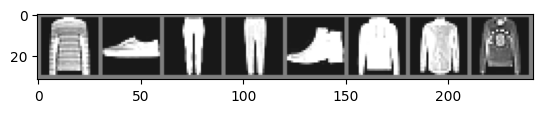

Pull-over Sneaker Pantalon Pantalon Bottine Pull-over Chemise Pull-over


In [10]:
classes = ['T-shirt/top', 'Pantalon', 'Pull-over', 'Robe', 'Manteau',
           'Sandale', 'Chemise', 'Sneaker', 'Sac', 'Bottine']

# Visualisation rapide
def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)), cmap='gray')
    plt.show()

dataiter = iter(trainloader)
images, labels = next(dataiter)
imshow(torchvision.utils.make_grid(images[:8]))
print(' '.join(f'{classes[labels[j]]}' for j in range(8)))

## Définition de l'architecture CNN de base

In [11]:
class SimpleCNN(nn.Module):
    def __init__(self, out_channels=16, first_conv_requires_grad=True):
        super().__init__()
        self.conv1 = nn.Conv2d(1, out_channels, kernel_size=3, padding=1, bias=False)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2)
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(out_channels * 14 * 14, 10)

        # Option pour geler la 1er couche
        if not first_conv_requires_grad:
            self.conv1.weight.requires_grad = False

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.flatten(x)
        x = self.fc(x)
        return x

    def set_fixed_kernel(self, kernel_tensor):
        """(shape attendue: 1×1×3×3 ou 1×C×3×3)"""
        with torch.no_grad():
            repeated = kernel_tensor.repeat(self.conv1.out_channels, 1, 1, 1)
            self.conv1.weight.copy_(repeated)

## Fonction d'entrainement et d'évaluation

In [12]:
def train_model(model, trainloader, epochs=8, lr=0.001):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr) if model.conv1.weight.requires_grad else \
                optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for inputs, labels in tqdm(trainloader, desc=f"Epoch {epoch+1}/{epochs}"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch {epoch+1} – Loss: {running_loss/len(trainloader):.4f}")
    return model


def evaluate_model(model, testloader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='macro')
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)

    return acc, f1, prec

## Définition des kernels fixes

In [13]:
kernels = {
    "Identity": torch.tensor([[[[ 0.,  0.,  0.],
                                [ 0.,  1.,  0.],
                                [ 0.,  0.,  0.]]]]),

    "Sharpen": torch.tensor([[[[ 0., -1.,  0.],
                               [-1.,  5., -1.],
                               [ 0., -1.,  0.]]]]),

    "Box Blur": torch.tensor([[[[1/9, 1/9, 1/9],
                                [1/9, 1/9, 1/9],
                                [1/9, 1/9, 1/9]]]]),

    "Gaussian Blur 3x3": torch.tensor([[[[1/16, 2/16, 1/16],
                                         [2/16, 4/16, 2/16],
                                         [1/16, 2/16, 1/16]]]]),

    "Sobel Horizontal": torch.tensor([[[[-1.,  0.,  1.],
                                        [-2.,  0.,  2.],
                                        [-1.,  0.,  1.]]]]),

    "Laplacian": torch.tensor([[[[ 0.,  1.,  0.],
                                 [ 1., -4.,  1.],
                                 [ 0.,  1.,  0.]]]])
}

## Entraînement et Evaluation

In [14]:
results = {}

# Version référence
print("\n--- CNN standard")
model_learned = SimpleCNN(out_channels=16, first_conv_requires_grad=True)
model_learned = train_model(model_learned, trainloader, epochs=10)
acc, f1, prec = evaluate_model(model_learned, testloader)
results["Learned kernels"] = (acc, f1, prec)
print(f"Accuracy: {acc:.4f} | F1-macro: {f1:.4f} | Precision-macro: {prec:.4f}\n")

# Versions avec kernels Fixe
for name, kernel in kernels.items():
    print(f"\n -[ {name} ]-")
    model_fixed = SimpleCNN(out_channels=16, first_conv_requires_grad=False)
    model_fixed.set_fixed_kernel(kernel.to(device))
    model_fixed = train_model(model_fixed, trainloader, epochs=10)
    acc, f1, prec = evaluate_model(model_fixed, testloader)
    results[name] = (acc, f1, prec)
    print(f"Accuracy: {acc:.4f} | F1-macro: {f1:.4f} | Precision-macro: {prec:.4f}")


--- CNN standard


Epoch 1/10: 100%|██████████| 469/469 [00:12<00:00, 36.76it/s]


Epoch 1 – Loss: 0.4576


Epoch 2/10: 100%|██████████| 469/469 [00:12<00:00, 36.81it/s]


Epoch 2 – Loss: 0.3262


...

Epoch 9/10: 100%|██████████| 469/469 [00:12<00:00, 36.54it/s]


Epoch 9 – Loss: 0.6656


Epoch 10/10: 100%|██████████| 469/469 [00:12<00:00, 36.10it/s]

Epoch 10 – Loss: 0.6733


Accuracy: 0.7743 | F1-macro: 0.7764 | Precision-macro: 0.7921


## Affichage des resultats

In [15]:
print("\n" + "="*70)
print("RESULTATS COMPARATIFS")
print("-"*70)
print(f"{'Kernel':<21}|{ 'Accuracy'}| {'F1-macro'}|{'Precision-macro'}")
print("-"*70)
for name, (acc, f1, prec) in results.items():
    print(f"{name:<20} | {acc:.4f} | {f1:.4f} | {prec:.4f}")


RESULTATS COMPARATIFS
----------------------------------------------------------------------
Kernel               |Accuracy| F1-macro|Precision-macro
----------------------------------------------------------------------
Learned kernels      | 0.9010 | 0.9009 | 0.9012
Identity             | 0.7682 | 0.7649 | 0.7759
Sharpen              | 0.7422 | 0.7439 | 0.7705
Box Blur             | 0.8058 | 0.8023 | 0.8018
Gaussian Blur 3x3    | 0.7839 | 0.7832 | 0.7942
Sobel Horizontal     | 0.8208 | 0.8184 | 0.8220
Laplacian            | 0.7743 | 0.7764 | 0.7921


## Visualisation d’exemples de **Filtres appris** vs **Fixes**

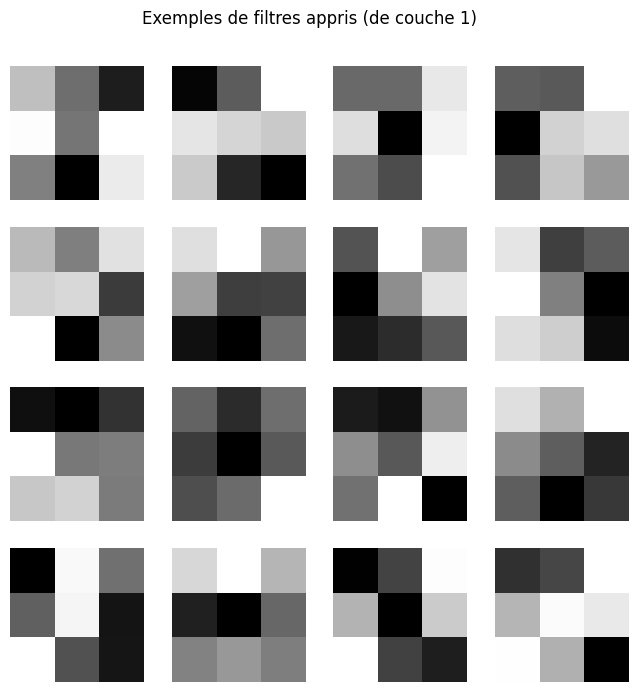

In [16]:
# Montrer les 16 filtres appris de la version standard
with torch.no_grad():
    filters = model_learned.conv1.weight.cpu().squeeze(1).numpy()  # shape (16,28? non -> 3x3)
    fig, axes = plt.subplots(4, 4, figsize=(8,8))
    for i, ax in enumerate(axes.flat):
        ax.imshow(filters[i], cmap='gray')
        ax.axis('off')
    plt.suptitle("Exemples de filtres appris (de couche 1)", y=0.95)
    plt.show()

